In [3]:
pip install statsmodels scikit-learn seaborn

  Using cached statsmodels-0.14.6-cp310-cp310-macosx_11_0_arm64.whl (10.0 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 10.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 6.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import itertools

In [5]:
data = pd.read_csv("../data/visitor_prediction_features_snapshot.csv")
data["month"] = pd.to_datetime(data["month"])

data = data.sort_values(["country", "month"]).reset_index(drop=True)
data.head()

,country,month,visitor_arrivals,gdp,exchange_rate,public_holiday_count,aircraft_passengers,traffic_volume,hotel_rate,hotel_occupancy
0,Australia,1978-01-01,20379.0,135608.0,NaN,2,NaN,NaN,NaN,NaN
1,Australia,1978-02-01,18852.0,135608.0,NaN,0,NaN,NaN,NaN,NaN
2,Australia,1978-03-01,20819.0,135608.0,NaN,9,NaN,NaN,NaN,NaN
3,Australia,1978-04-01,18697.0,135608.0,NaN,1,NaN,NaN,NaN,NaN
4,Australia,1978-05-01,19797.0,135608.0,NaN,3,NaN,NaN,NaN,NaN


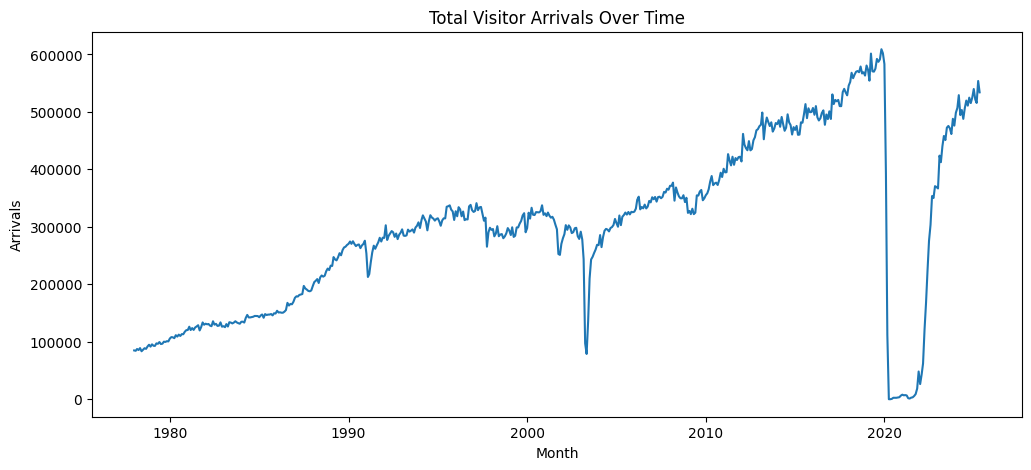

In [7]:
ts_data = (
    data
    .groupby("month")["visitor_arrivals"]
    .sum()
    .reset_index()
    .sort_values("month")
)

plt.figure(figsize=(12, 5))
plt.plot(ts_data["month"], ts_data["visitor_arrivals"])
plt.title("Total Visitor Arrivals Over Time")
plt.xlabel("Month")
plt.ylabel("Arrivals")
plt.show()

In [9]:
ts_data["log_arrivals"] = np.log1p(ts_data["visitor_arrivals"])

result = adfuller(ts_data["log_arrivals"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.7875511707399925
p-value: 5.744793185910805e-05


In [10]:
ts_data["diff_1"] = ts_data["log_arrivals"].diff()
adfuller_result_diff_1 = adfuller(ts_data["diff_1"].dropna())
print("ADF Statistic:", adfuller_result_diff_1[0])
print("p-value:", adfuller_result_diff_1[1])

ADF Statistic: -6.004192265518593
p-value: 1.6302431151577285e-07


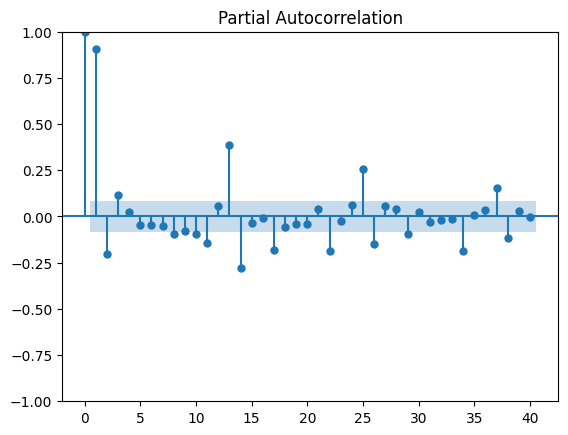

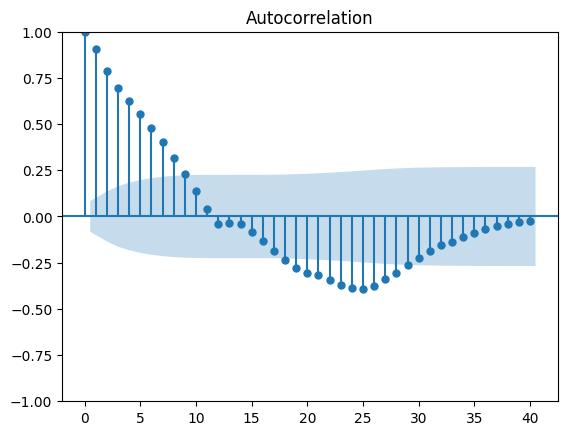

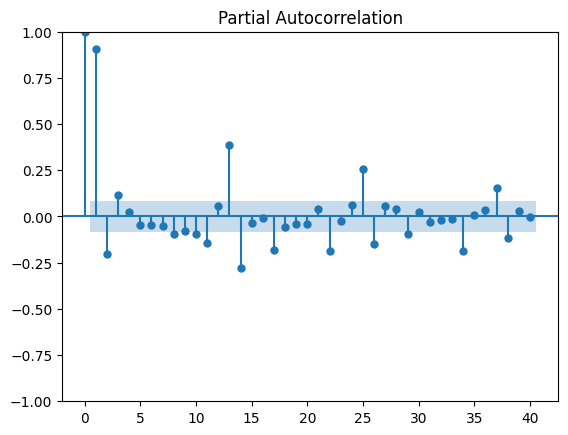

In [11]:
ts_data["diff_12"] = ts_data["log_arrivals"].diff(12)

plot_acf(ts_data["diff_12"].dropna(), lags=40)
plot_pacf(ts_data["diff_12"].dropna(), lags=40)

In [12]:
# Arima
model = ARIMA(ts_data["log_arrivals"], order=(1,1,1))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:           log_arrivals   No. Observations:                  569
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -123.562
Date:                Thu, 09 Apr 2026   AIC                            253.124
Time:                        09:59:51   BIC                            266.150
Sample:                             0   HQIC                           258.207
                                - 569                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0727      0.054     -1.346      0.178      -0.178       0.033
ma.L1          0.3202      0.055      5.835      0.000       0.213       0.428
sigma2         0.0905      0.001    177.538      0.0

In [13]:
model = SARIMAX(
    ts_data["log_arrivals"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()
print(result.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.74711D-01    |proj g|=  9.64380D-01


 This problem is unconstrained.



At iterate    5    f=  3.01777D-01    |proj g|=  1.49250D-01

At iterate   10    f=  2.60082D-01    |proj g|=  1.21837D-01

At iterate   15    f=  2.52353D-01    |proj g|=  9.88850D-03

At iterate   20    f=  2.52072D-01    |proj g|=  9.04733D-04

At iterate   25    f=  2.52064D-01    |proj g|=  1.25687D-03

At iterate   30    f=  2.52063D-01    |proj g|=  2.25792D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     30     41      1     0     0   2.258D-05   2.521D-01
  F =  0.25206303133737357     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
                                     SARIMAX Result

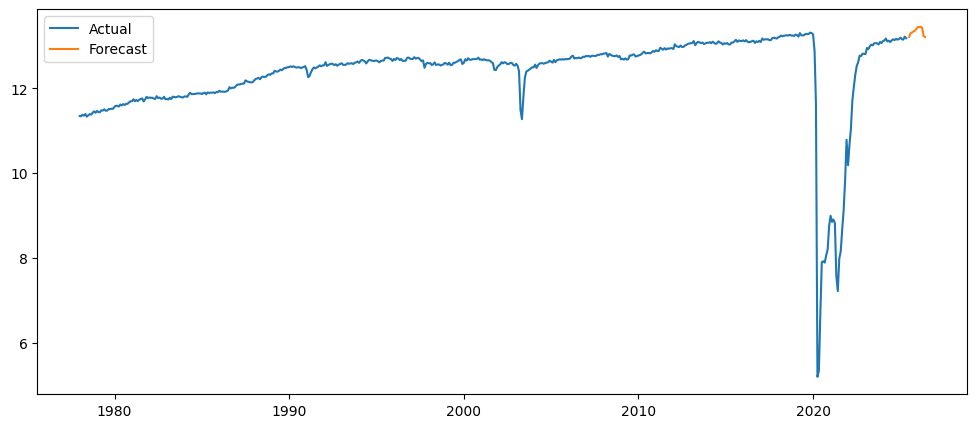

In [14]:
forecast = result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean

plt.figure(figsize=(12, 5))
plt.plot(ts_data["month"], ts_data["log_arrivals"], label="Actual")
plt.plot(pd.date_range(ts_data["month"].iloc[-1], periods=13, freq="M")[1:], forecast_mean, label="Forecast")
plt.legend()
plt.show()

In [21]:
train = ts_data[:-24]
test = ts_data[-24:]

In [20]:
p = q = range(0, 3)
d = [1]

P = Q = range(0, 2)
D = [1]
s = [12]

results = []

for order in itertools.product(p, d, q):
    for seasonal_order_base in itertools.product(P, D, Q, s):
        try:
            model = SARIMAX(
                train["log_arrivals"],
                order=order,
                seasonal_order=seasonal_order_base,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False)

            pred = fitted.get_forecast(steps=len(test)).predicted_mean
            rmse = np.sqrt(mean_squared_error(test["log_arrivals"], pred))

            results.append({
                "order": order,
                "seasonal_order": seasonal_order_base,
                "aic": fitted.aic,
                "bic": fitted.bic,
                "rmse_log": rmse
            })

        except Exception:
            continue

results_df = pd.DataFrame(results).sort_values(by=["rmse_log", "aic"])
results_df.head(10)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,aic,bic,rmse_log
21,"(1, 1, 2)","(0, 1, 1, 12)",300.329114,321.569329,0.099705
29,"(2, 1, 1)","(0, 1, 1, 12)",296.452635,317.702511,0.111133
23,"(1, 1, 2)","(1, 1, 1, 12)",307.262909,332.751166,0.121680
31,"(2, 1, 1)","(1, 1, 1, 12)",302.952919,328.452770,0.126554
33,"(2, 1, 2)","(0, 1, 1, 12)",297.674897,323.163155,0.133519
25,"(2, 1, 0)","(0, 1, 1, 12)",298.294880,315.302496,0.140430
35,"(2, 1, 2)","(1, 1, 1, 12)",303.862732,333.599032,0.146180
27,"(2, 1, 0)","(1, 1, 1, 12)",304.802952,326.052828,0.153298
9,"(0, 1, 2)","(0, 1, 1, 12)",304.508873,321.501044,0.166246
17,"(1, 1, 1)","(0, 1, 1, 12)",304.522455,321.522356,0.172423


In [31]:
model = SARIMAX(train["log_arrivals"], order=(1,1,2), seasonal_order=(0,1,1,12), enforce_stationarity=False, enforce_invertibility=False)
result = model.fit()

pred = result.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.63412D-01    |proj g|=  9.68744D-01

At iterate    5    f=  2.68009D-01    |proj g|=  1.76549D-01

At iterate   10    f=  2.66767D-01    |proj g|=  4.22767D-03

At iterate   15    f=  2.66362D-01    |proj g|=  2.76449D-03

At iterate   20    f=  2.66357D-01    |proj g|=  1.17324D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     20     25      1     0     0   1.173D-05   2.664D-01
  F =  0.26635698564292465     

CONVERG

In [32]:
rmse = np.sqrt(mean_squared_error(test["log_arrivals"], pred_mean))
print("RMSE:", rmse)

RMSE: 0.09970498696636007


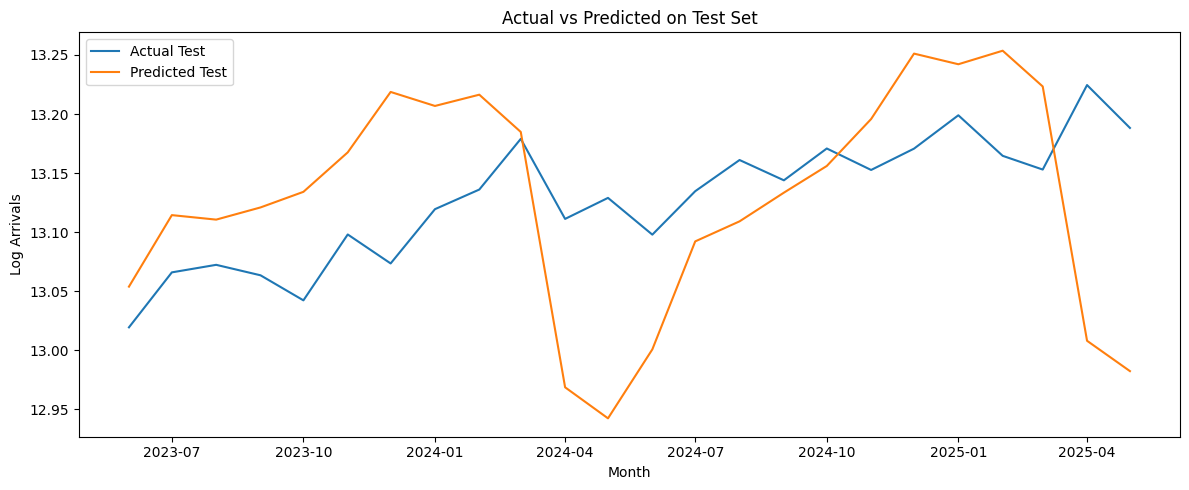

In [33]:
plt.figure(figsize=(12,5))
plt.plot(test["month"], test["log_arrivals"], label="Actual Test")
plt.plot(test["month"], pred_mean, label="Predicted Test")
plt.title("Actual vs Predicted on Test Set")
plt.xlabel("Month")
plt.ylabel("Log Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

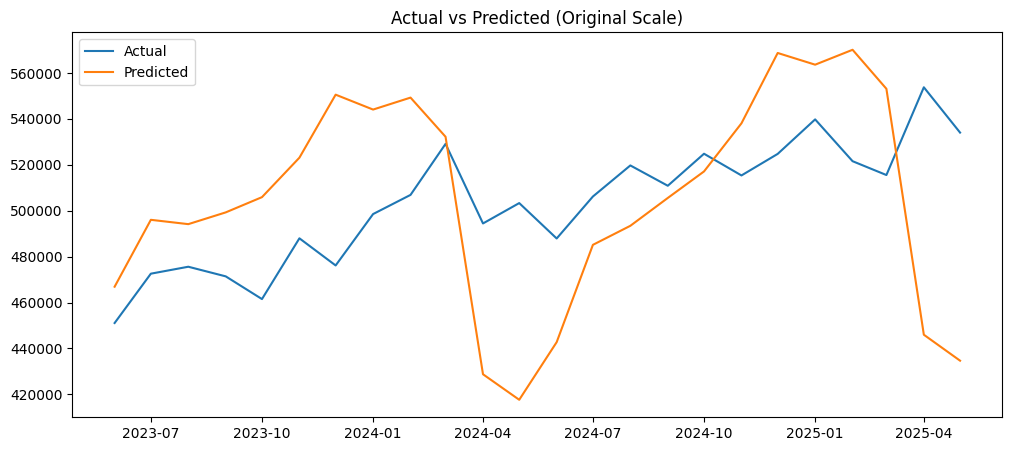

In [34]:
actual_test = np.expm1(test["log_arrivals"])
pred_test = np.expm1(pred_mean)

plt.figure(figsize=(12,5))
plt.plot(test["month"], actual_test, label="Actual")
plt.plot(test["month"], pred_test, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Original Scale)")
plt.show()